# Stock Price Exploratory Data Analysis (EDA)
This notebook performs basic EDA for stock **Adjusted Close prices** including:
1. Time Series Plot
2. Distribution Histogram
3. Box Plot (Outlier Detection)
4. Daily Return Distribution
5. ACF Plot
6. PACF Plot


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load dataset
df = pd.read_csv('yahoo_stock.csv')

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


## 1. Time Series Plot

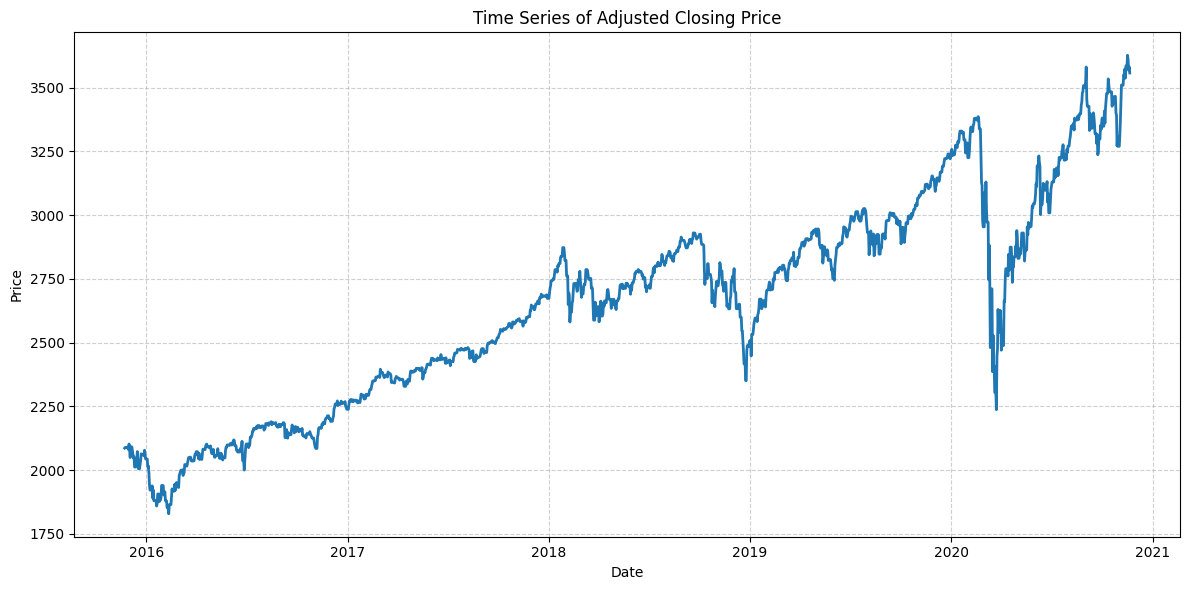

In [2]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Adj Close'], linewidth=2)

plt.title('Time Series of Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Distribution Histogram

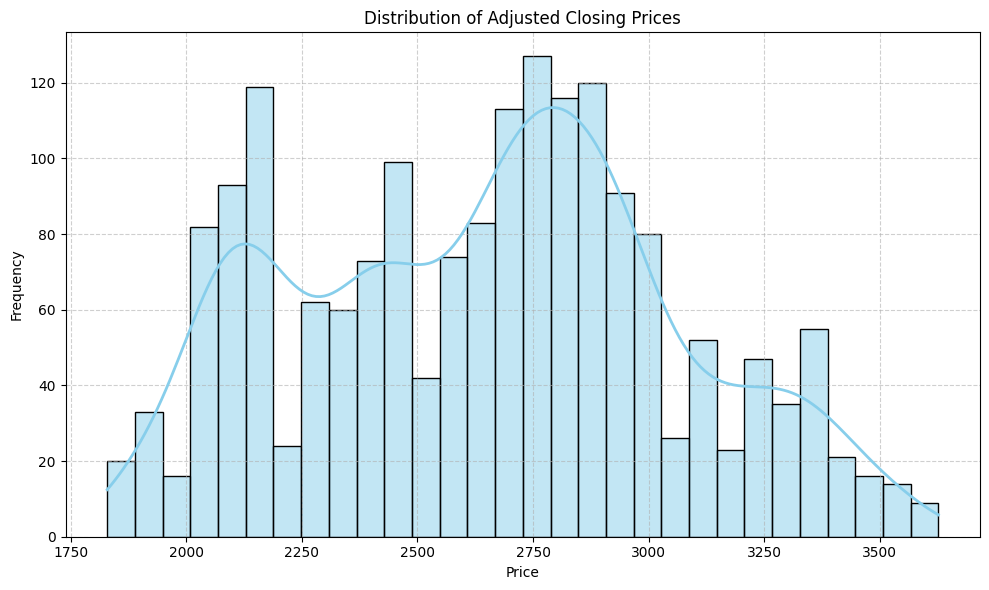

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Adj Close'],
    bins=30,
    kde=True,
    color='skyblue',                 # สีแท่ง histogram
    line_kws={'color':'red', 'linewidth':2}  # สีเส้น KDE
)

plt.title('Distribution of Adjusted Closing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Box Plot (Outlier Detection)

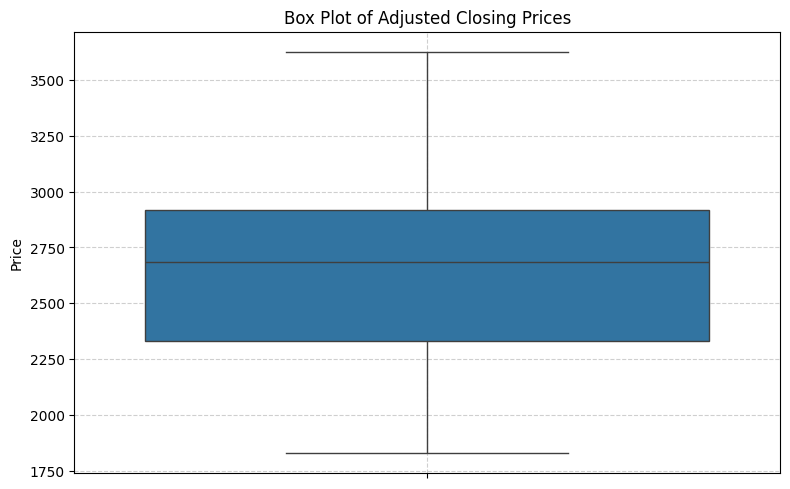

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Adj Close'])

plt.title('Box Plot of Adjusted Closing Prices')
plt.ylabel('Price')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Daily Return Distribution

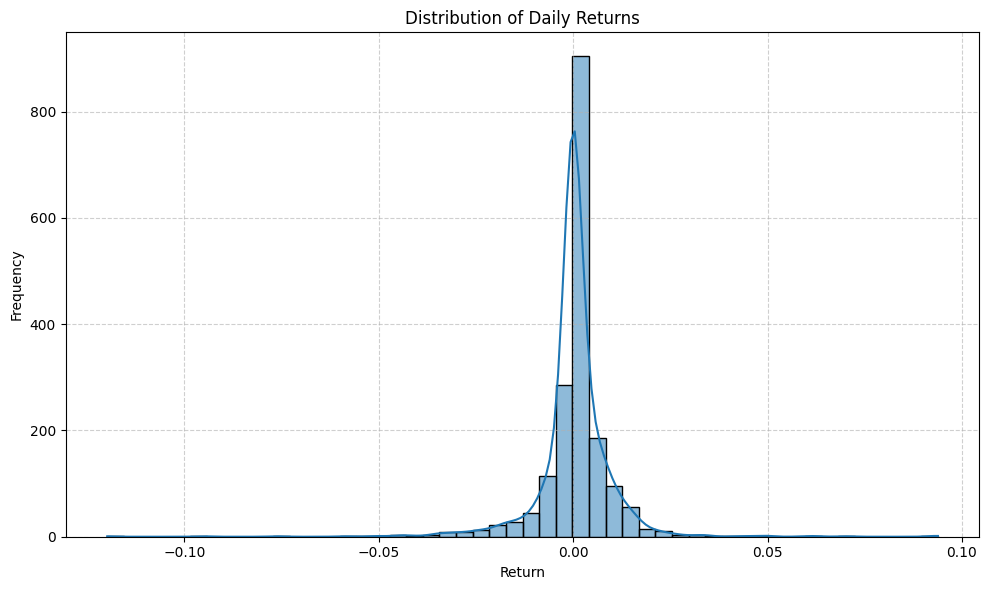

In [5]:
df['Return'] = df['Adj Close'].pct_change()

plt.figure(figsize=(10,6))
sns.histplot(df['Return'].dropna(), bins=50, kde=True)

plt.title('Distribution of Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Autocorrelation Function (ACF)

<Figure size 1000x500 with 0 Axes>

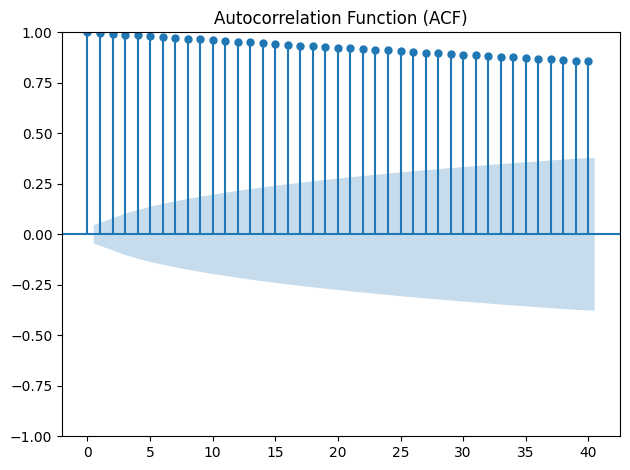

In [6]:
plt.figure(figsize=(10,5))
plot_acf(df['Adj Close'].dropna(), lags=40)

plt.title('Autocorrelation Function (ACF)')

plt.tight_layout()
plt.show()

## 6. Partial Autocorrelation Function (PACF)

<Figure size 1000x500 with 0 Axes>

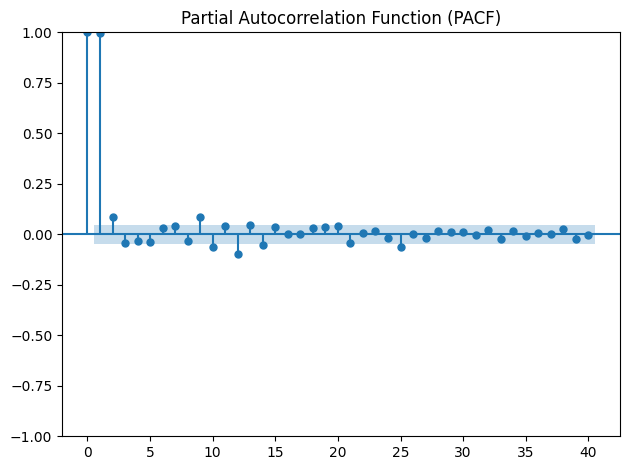

In [7]:
plt.figure(figsize=(10,5))
plot_pacf(df['Adj Close'].dropna(), lags=40)

plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()